# Explora aquí

#### Importamos librerias necesarias

In [181]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import io
import pandas as pd
import numpy as np

#### Paso 1:

Descargamos HTML

In [182]:
url = "https://books.toscrape.com/catalogue/category/books/music_14/index.html"
# url = "https://books.toscrape.com/" #probando con mas datos, falle por que solo traje la pagina 1 con 20 libros.
header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
response = requests.get(url, headers= header)
response.status_code

200

#### Verificamos el Response = 200

Visualizamos el string y su tamaño

In [183]:
len(response.content), response.content

(40193,
 b'\n\n<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    Music | \n     Books to Scrape - Sandbox\n\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:29" />\n        <meta name="description" content="\n    \n" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link 

#### Tenemos ya el documento como una cadena de String

Ahora aplicamos el soap

In [184]:
soup = BeautifulSoup(response.content)
soup



<!DOCTYPE html>

<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en-us"> <!--<![endif]-->
<head>
<title>
    Music | 
     Books to Scrape - Sandbox

</title>
<meta content="text/html; charset=utf-8" http-equiv="content-type"/>
<meta content="24th Jun 2016 09:29" name="created"/>
<meta content="
    
" name="description"/>
<meta content="width=device-width" name="viewport"/>
<meta content="NOARCHIVE,NOCACHE" name="robots"/>
<!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
<!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
<link href="../../../../static/oscar/favicon.ico" rel="shortcut icon"/>
<link href="../../../../static/oscar/css/styles.css" rel="stylesheet" 

Tenemos organizado los datos como BeautifulSoup

Procederemos a sacar la lista de productos

In [185]:
products = soup.find_all('article', class_='product_pod')
len(products), products[0]

(13,
 <article class="product_pod">
 <div class="image_container">
 <a href="../../../rip-it-up-and-start-again_986/index.html"><img alt="Rip it Up and Start Again" class="thumbnail" src="../../../../media/cache/81/c4/81c4a973364e17d01f217e1188253d5e.jpg"/></a>
 </div>
 <p class="star-rating Five">
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 <i class="icon-star"></i>
 </p>
 <h3><a href="../../../rip-it-up-and-start-again_986/index.html" title="Rip it Up and Start Again">Rip it Up and ...</a></h3>
 <div class="product_price">
 <p class="price_color">£35.02</p>
 <p class="instock availability">
 <i class="icon-ok"></i>
     
         In stock
     
 </p>
 <form>
 <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
 </form>
 </div>
 </article>)

De momento notamos que tenemos 13 articulos (coincide con el filtrado que tenemos en la pagina)

Tomaremos el nombre, el precio, y el ranking.

In [186]:
ranking_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
list_products = []

for product in products:
    
    product_title = product.find('h3').find('a')['title']

    product_price = product.find('p', class_='price_color')
    product_price_float = float(product_price.text[1:])

    ranking = product.find('p', class_='star-rating')
    ranking_work = ranking.get('class')
    raking = 0
    for foo in ranking_work:              
        if foo in ranking_map:            
            raking = ranking_map[foo]     
            break
    list_products.append({"title": product_title, "price":product_price_float, "rating": raking})


list_products[:3], len(list_products)

([{'title': 'Rip it Up and Start Again', 'price': 35.02, 'rating': 5},
  {'title': 'Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991',
   'price': 57.25,
   'rating': 3},
  {'title': 'How Music Works', 'price': 37.32, 'rating': 2}],
 13)

Tenemos un diccionario que podremos trabajar como un dataFrame

Ahora a convertirlo

In [187]:
df = pd.DataFrame(list_products)
df

,title,price,rating
0,Rip it Up and Start Again,35.02,5
1,Our Band Could Be Your Life: Scenes from the A...,57.25,3
2,How Music Works,37.32,2
3,Love Is a Mix Tape (Music #1),18.03,1
4,Please Kill Me: The Uncensored Oral History of...,31.19,4
5,Kill 'Em and Leave: Searching for James Brown ...,45.05,5
6,"Chronicles, Vol. 1",52.60,2
7,This Is Your Brain on Music: The Science of a ...,38.40,1
8,Orchestra of Exiles: The Story of Bronislaw Hu...,12.36,3
9,No One Here Gets Out Alive,20.02,5


Podemos ver un DataFrame de nuestro web scraping

ahora veamos un grafico

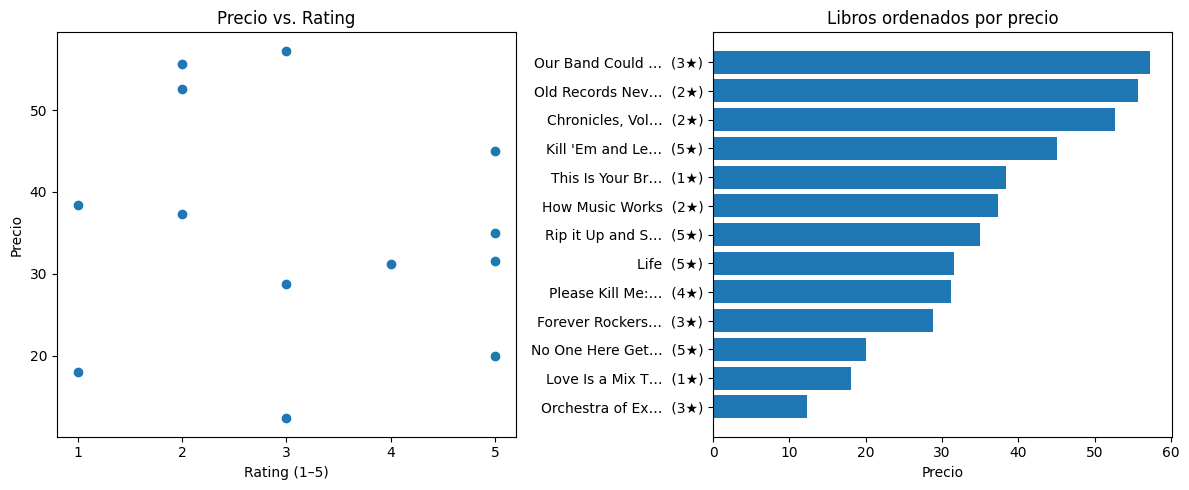

In [188]:
# Definimos los subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Primer gráfico
ax[0].scatter(df['rating'], df['price'])
ax[0].set_xticks([1,2,3,4,5])
ax[0].set_xlabel("Rating (1–5)")
ax[0].set_ylabel("Precio")
ax[0].set_title("Precio vs. Rating")

# 2do
ordered = df.sort_values("price", ascending=True)
prices  = pd.to_numeric(ordered["price"])
ratings = pd.to_numeric(ordered["rating"]).fillna(0).astype(int).astype(str)
titles  = ordered["title"].fillna("").astype(str)
short_titles = np.where(titles.str.len() > 15, titles.str[:15] + "…", titles)

labels = short_titles + "  (" + ratings + "★)"  


ax[1].barh(labels, prices)
ax[1].set_xlabel("Precio")
ax[1].set_title("Libros ordenados por precio")

plt.tight_layout()
plt.show()

#### Observaciones

Podemos ver que no hay una relacion directa entre el rantink y el precio. Con el grafico de dispersion vemos que el precio no ha interferido con el ranting. Quizas si sacaramos mas informacion del web scraping podriamos tener datos sobre los cuales podemos predecir resultados sobre futuros ranting según el precio de salida.  